# Assignment 3: Supervised Land Use Classification with Google Earth Engine
**Tianyu (Neve) Zhang** , Mar 6th, 2025

I collaborated with Ziyi Guo to complete labelling GEE data of Charleston, NC region for this assignment. Upon collection of data from Google Earth Engine, the labelling was mannually completed in ArcGIS Pro. We classified the following Land Use labels as:

- `Urban`: Land with artificially built structures and infrastructure, including buildings and paved roads.
- `Bare`: Barren land with little or no trees, with sparse vegetation mixed with soil, no artificial construct. Such as playgrounds or cemeteries.
- `Covered`: Heavily vegeated lands, such as forest.
- `Water`: Surface of river, ocean, and ponds.

*Disclaimer*: The following AI tool was consulted to revise codes for this project.
- OpenAI. (2025). ChatGPT (Mar 6 version) [Large language model]. https://chat.openai.com/chat.

In [1]:
import ee
import geemap
import ipywidgets as widgets
from IPython.display import display
import leafmap

In [2]:
ee.Authenticate()
ee.Initialize(project='ee-tianyuzh')

In [3]:
# Define area of interest (AOI)
charleston_aoi = ee.Geometry.Rectangle([-80.30, 32.55, -79.75, 33.00])

## Download TIFF image for labelling

(This section was completed before labeling and not re-run.)

In [4]:
#charleston_image = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
                 #.filterBounds(charleston_aoi)
                 #.filterDate('2022-01-01', '2023-12-31') 
                 #.sort('CLOUD_COVER') 
                 #.first()  # Take the best one
                 #.select(["SR_B1", "SR_B2", "SR_B3", "SR_B4", "SR_B5", "SR_B6", "SR_B7"])
#)

In [5]:
# Export image for labeling processing
#task = ee.batch.Export.image.toDrive(
    #image=charleston_image,
    #description="Landsat_Charleston2",
    #folder="GEE_Exports",
    #fileNamePrefix="Landsat_Charleston2",
    #scale=30,
    #region=charleston_aoi,
    #fileFormat="GeoTIFF"
#)

#task.start()
#print("Export started. Check Google Drive for the full image.")

## Download DEM Data

(This section was completed before labeling and not re-run.)

In [6]:
#charleston_dem = ee.Image("USGS/SRTMGL1_003").clip(charleston_aoi)

#task_dem = ee.batch.Export.image.toDrive(
    #image=charleston_dem,
    #description="Charleston_DEM",
    #folder="GEE_Exports",
    #fileNamePrefix="Charleston_DEM",
    #scale=30,  # 30m resolution
    #region=charleston_aoi,
    #fileFormat="GeoTIFF",
    #crs="EPSG:4326"
#)

#task_dem.start()
#print("Exporting DEM to Google Drive.")

In [7]:
# File paths
#dem_path = "C:/Users/ztyuu/Desktop/Spring2025/MUSA 650/musa-650-spring-2025/musa-650-guo-zhang-submissions/assignment-2/Charleston_DEM.tif"
#output_dem_path = "C:/Users/ztyuu/Desktop/Spring2025/MUSA 650/musa-650-spring-2025/musa-650-guo-zhang-submissions/assignment-2/Processed_DEM.tif"

# Open the DEM file
#with rasterio.open(dem_path) as src:
    #dst_crs = CRS.from_epsg(32617)  # Correct CRS format

    #transform, width, height = calculate_default_transform(
        #src.crs, dst_crs, src.width, src.height, *src.bounds
    #)

    ## Update metadata
    #kwargs = src.meta.copy()
    #kwargs.update({
        #"crs": dst_crs,
        #"transform": transform,
        #"width": width,
        #"height": height
    #})

    # Open the output file for writing
    #with rasterio.open(output_dem_path, "w", **kwargs) as dst:
        #for i in range(1, src.count + 1): 
            #reproject(
                #source=rasterio.band(src, i),
                #destination=rasterio.band(dst, i), 
                #src_transform=src.transform,
                #src_crs=src.crs,
                #dst_transform=transform,
                #dst_crs=dst_crs,
                #resampling=Resampling.nearest 
            #)

#print("DEM reprojected successfully.")
#print("New DEM saved as:", output_dem_path)

## Load Labelled Data

In [8]:
import geopandas as gpd
import rasterio
import numpy as np
import pandas as pd
from rasterio.transform import rowcol
from sklearn.preprocessing import MinMaxScaler

In [9]:
# Load the Landsat labels (points)
labels = gpd.read_file("C:/Users/ztyuu/Desktop/Spring2025/MUSA 650/musa-650-spring-2025/musa-650-guo-zhang-submissions/assignment-2/Labelling/data/Labels_Merged/Labels_Export.shp")

In [10]:
# Load the Landsat raster
tiff_path = "C:/Users/ztyuu/Desktop/Spring2025/MUSA 650/musa-650-spring-2025/musa-650-guo-zhang-submissions/assignment-2/Landsat_Charleston2.tif"

with rasterio.open(tiff_path) as src:
    bands = src.read()  # Read all bands
    transform = src.transform  # Get transformation matrix

Processed DEM data retrieved from GEE to calculate elevation and slope at each label point. Used MinMaxScaler() to normalize elevation and slope.

In [11]:
# Load the DEM raster
dem_path = "C:/Users/ztyuu/Desktop/Spring2025/MUSA 650/musa-650-spring-2025/musa-650-guo-zhang-submissions/assignment-2/Processed_DEM.tif"

with rasterio.open(dem_path) as dem_src:
    dem_data = dem_src.read(1).astype(np.float32)  # Read DEM band
    dem_transform = dem_src.transform  # Get transformation matrix

    # Compute slope using NumPy gradients
    dx, dy = np.gradient(dem_data, axis=(1, 0))  # Gradient in X (East-West) and Y (North-South)
    slope = np.sqrt(dx**2 + dy**2)  # Slope magnitude

    # Normalize DEM Elevation & Slope
    scaler = MinMaxScaler()

    dem_data_flat = dem_data.flatten().reshape(-1, 1)  # Flatten and reshape for scaling
    slope_flat = slope.flatten().reshape(-1, 1)  # Flatten and reshape for scaling

    dem_data_scaled = scaler.fit_transform(dem_data_flat).reshape(dem_data.shape)  # Normalize elevation
    slope_scaled = scaler.fit_transform(slope_flat).reshape(slope.shape)  # Normalize slope

Calculated NDVI, NDBI, MNDWI indices; matched them to each feature point together with Elevation and Slope.

In [12]:
import numpy as np
from scipy.ndimage import gaussian_filter, sobel

# Precompute smoothed and edge-detected versions of the key datasets
ndvi_array = (bands[3] - bands[2]) / (bands[3] + bands[2] + 1e-10)  # Avoid division by zero
ndbi_array = (bands[4] - bands[3]) / (bands[4] + bands[3] + 1e-10)
mndwi_array = (bands[1] - bands[4]) / (bands[1] + bands[4] + 1e-10)

# Apply Gaussian filter for smoothing
ndvi_smoothed = gaussian_filter(ndvi_array, sigma=1)
ndbi_smoothed = gaussian_filter(ndbi_array, sigma=1)
mndwi_smoothed = gaussian_filter(mndwi_array, sigma=1)
elevation_smoothed = gaussian_filter(dem_data_scaled, sigma=1)
slope_smoothed = gaussian_filter(slope_scaled, sigma=1)

# Apply Sobel filter for edge detection
ndvi_edges = np.hypot(sobel(ndvi_array, axis=0), sobel(ndvi_array, axis=1))
ndbi_edges = np.hypot(sobel(ndbi_array, axis=0), sobel(ndbi_array, axis=1))
mndwi_edges = np.hypot(sobel(mndwi_array, axis=0), sobel(mndwi_array, axis=1))
elevation_edges = np.hypot(sobel(dem_data_scaled, axis=0), sobel(dem_data_scaled, axis=1))
slope_edges = np.hypot(sobel(slope_scaled, axis=0), sobel(slope_scaled, axis=1))

def extract_features(x, y):
    row, col = rowcol(transform, x, y)  # Get Landsat row/col

    if 0 <= row < bands.shape[1] and 0 <= col < bands.shape[2]: 
        blue = bands[0, row, col]
        green = bands[1, row, col]
        red = bands[2, row, col]
        nir = bands[3, row, col]
        swir1 = bands[4, row, col]
        swir2 = bands[5, row, col]

        # Compute NDVI, NDBI, MNDWI
        ndvi = ndvi_array[row, col]
        ndbi = ndbi_array[row, col]
        mndwi = mndwi_array[row, col]

        # Extract DEM elevation & slope
        dem_row, dem_col = rowcol(dem_transform, x, y)

        if 0 <= dem_row < dem_data.shape[0] and 0 <= dem_col < dem_data.shape[1]:
            elevation = dem_data_scaled[dem_row, dem_col]
            slope_value = slope_scaled[dem_row, dem_col]

            # Extract smoothed features
            ndvi_smooth = ndvi_smoothed[row, col]
            ndbi_smooth = ndbi_smoothed[row, col]
            mndwi_smooth = mndwi_smoothed[row, col]
            elevation_smooth = elevation_smoothed[dem_row, dem_col]
            slope_smooth = slope_smoothed[dem_row, dem_col]

            # Extract edge-detected features
            ndvi_edge = ndvi_edges[row, col]
            ndbi_edge = ndbi_edges[row, col]
            mndwi_edge = mndwi_edges[row, col]
            elevation_edge = elevation_edges[dem_row, dem_col]
            slope_edge = slope_edges[dem_row, dem_col]
        else:
            elevation, slope_value = None, None
            elevation_smooth, slope_smooth = None, None
            elevation_edge, slope_edge = None, None

        return [
            blue, green, red, nir, swir1, swir2, ndvi, ndbi, mndwi, elevation, slope_value,
            ndvi_smooth, ndbi_smooth, mndwi_smooth, elevation_smooth, slope_smooth,
            ndvi_edge, ndbi_edge, mndwi_edge, elevation_edge, slope_edge
        ]
    else:
        return [None] * 21

labels["features"] = labels.apply(lambda row: extract_features(row.geometry.x, row.geometry.y), axis=1)

feature_names = [
    "Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2",
    "NDVI", "NDBI", "MNDWI",
    "Elevation", "Slope",
    "Smoothed_NDVI", "Smoothed_NDBI", "Smooothed_MNDWI", "Smoothed_Elevation", "Smoothed_Slope",
    "Edge_NDVI", "Edge_NDBI", "Edge_MNDWI", "Edge_Elevation", "Edge_Slope"
]

# Convert extracted features into DataFrame columns
labels[feature_names] = pd.DataFrame(labels["features"].tolist(), index=labels.index)

# Drop the temporary features column
labels.drop(columns=["features"], inplace=True)

print(labels.head())

   Class                            geometry   Blue  Green    Red    NIR  \
0  Urban  POINT Z (599843.685 3627591.012 0)  16192  17345  18638  19995   
1  Urban  POINT Z (600279.897 3628745.818 0)  11689  12060  13111  13282   
2  Urban   POINT Z (600075.181 3628696.26 0)   9973  10171  10639  10937   
3  Urban  POINT Z (599924.696 3628854.392 0)   9706   9947  10855  10902   
4  Urban  POINT Z (599708.316 3628748.592 0)   8964   9125   9945  10164   

   SWIR1  SWIR2      NDVI      NDBI  ...  Smoothed_NDVI  Smoothed_NDBI  \
0  21988  20936  0.035125  0.047472  ...       0.027448       0.038615   
1  13390  14096  0.006479  0.004049  ...       0.241195       0.331283   
2  13199  13601  0.013812  0.093719  ...       0.015334       0.113860   
3  15330  14354  0.002160  0.168801  ...       1.195166       0.177338   
4  14272  13456  0.010891  0.168113  ...       0.360663       0.151176   

   Smooothed_MNDWI  Smoothed_Elevation  Smoothed_Slope  Edge_NDVI  Edge_NDBI  \
0         1.709013

## Modelling

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

### Assigning unique numeric label to each class

In [14]:
# Remove rows where Class is None
labels = labels[labels["Class"].notna()]

In [15]:
# Convert class labels to numeric
class_mapping = {label: idx for idx, label in enumerate(labels["Class"].unique())}
labels["Class_Num"] = labels["Class"].map(class_mapping)

print("Class label mapping:", class_mapping)

Class label mapping: {'Urban': 0, 'Covered': 1, 'Bare': 2, 'Water': 3}


### Training and Predicting

The following process splitted the data into a training dataset (70%) and a validation dataset (30%). Then, a random forest model with n_estimators = 100 was trained on all bands, together with the five engineered features (NDVI, NDBI, MNDWI, Elevation, Slope).

Overall, the model demonstrated good predictive performance on the data gathered. With an accuracy of 0.842, it indicates that 84.2% of the predictions matched the actual land cover classifications. Additionally, the model obtained a Kappa Coefficient of 0.79, suggesting substantial agreement beyond chance.

In [16]:
X = labels[["Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2", "NDVI", "NDBI", "MNDWI", "Elevation", "Slope"]].values
y = labels["Class_Num"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7)

mod = RandomForestClassifier(n_estimators=100, random_state=7)
mod.fit(X_train, y_train)

# Evaluate model accuracy
y_pred = mod.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)  # Compute accuracy
kappa = cohen_kappa_score(y_test, y_pred)  # Compute kappa statistic

print("Model Accuracy:", accuracy)
print("Model Kappa Coefficient:", kappa)

Model Accuracy: 0.8421052631578947
Model Kappa Coefficient: 0.7878899251160013


In [17]:
# Create a DataFrame for model performance metrics
metrics_df = pd.DataFrame({
    "Metric": ["Model Accuracy", "Kappa Coefficient"],
    "Value": [accuracy, kappa]
})

# Save Accuracy & Kappa metrics to CSV
metrics_df.to_csv("accuracy_metrics.csv", index=False)

### Training with Kernel Filtered Spectual Features

**For bonus points, consider adding kernel filters (e.g., edge detection, smoothing) to see if they improve model performance.**

I tested out using filtered spectual features here, but the model result did not significantly improve, so I decided to go with the baseline model.

#### Smoothed

In [18]:
X1 = labels[["Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2", 
           "Smoothed_NDVI", "Smoothed_NDBI", "Smooothed_MNDWI", "Smoothed_Elevation", "Smoothed_Slope"]].values
y1 = labels["Class_Num"].values

X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.3, random_state=8)

mod1 = RandomForestClassifier(n_estimators=100, random_state=8)
mod1.fit(X_train1, y_train1)

# Evaluate model accuracy
y_pred1 = mod1.predict(X_test1)

accuracy1 = accuracy_score(y_test1, y_pred1)  # Compute accuracy
kappa1 = cohen_kappa_score(y_test1, y_pred1)  # Compute kappa statistic

print("Smooth Model Accuracy:", accuracy1)
print("Smooth Model Kappa Coefficient:", kappa1)

Smooth Model Accuracy: 0.8187134502923976
Smooth Model Kappa Coefficient: 0.7509747733358387


#### Edge Detection

In [19]:
X2 = labels[["Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2", 
           "Edge_NDVI", "Edge_NDBI", "Edge_MNDWI", "Edge_Elevation", "Edge_Slope"]].values
y2 = labels["Class_Num"].values

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.3, random_state=8)

mod2 = RandomForestClassifier(n_estimators=100, random_state=8)
mod2.fit(X_train2, y_train2)

# Evaluate model accuracy
y_pred2 = mod2.predict(X_test2)

accuracy2 = accuracy_score(y_test2, y_pred2)  # Compute accuracy
kappa2 = cohen_kappa_score(y_test2, y_pred2)  # Compute kappa statistic

print("Smooth Model Accuracy:", accuracy2)
print("Smooth Model Kappa Coefficient:", kappa2)

Smooth Model Accuracy: 0.8070175438596491
Smooth Model Kappa Coefficient: 0.7343095249305522


**Using the validation data, generate a confusion matrix and calculate the overall accuracy, precision, and recall. Which classes were confused most often with each other? Why do you think this was?**

As previously mentioned, the model yielded an overall accuracy of 0.84. By computing the confusion matrix, the model yielded a precision of 0.847, and a recall of 0.875 (Urban), 0.911(Covered), 0.675(Bare) and 0.971(Water) respectively.

There is substantial confusion between urban and bare. This is to my surprise, as I expected more confusion between bare and water (due to wetlands scattered across Charleston), or bare and covered. A preliminary guess to why urban and bare land is often confused is that they tend to locate in proximity to one another, sharing very similar terrain qualities.

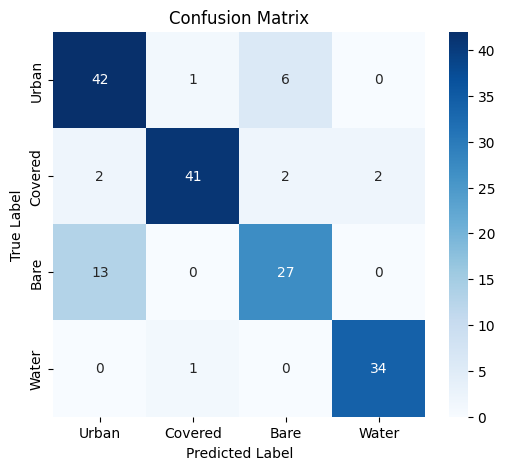

In [20]:
# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Display confusion matrix as a heatmap
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_mapping.keys(), yticklabels=class_mapping.keys())
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [21]:
from sklearn.metrics import classification_report

y_test_flat = y_test.flatten()
y_pred_flat = y_pred.flatten()

class_report = classification_report(y_test_flat, y_pred_flat, output_dict=True)
precision = class_report["weighted avg"]["precision"]

print(precision)

0.8469702635027208


In [22]:
class_labels = ["Urban", "Covered", "Bare", "Water"]
conf_matrix_df = pd.DataFrame(conf_matrix, index=class_labels, columns=class_labels)

conf_matrix_df.to_csv("confusion_matrix.csv")

**After training, analyze variable importance scores to justify each feature's inclusion. Identify which features are most influential in the classification. Report the final features that you keep in your model.**

All features demonstrated substantially balanced importance in the final model, with the minimum significance associated with "Elevation" (0.043). The blue band is the most influential predictor out of all features, attaining the highest significnace score of 0.148. 

In [23]:
# Get feature importances
feature_importance = mod.feature_importances_

# Feature names
feature_names = [ "Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2", "NDVI", "NDBI", "MNDWI", "Elevation", "Slope"]

# Sort features by importance
sorted_idx = np.argsort(feature_importance)

# Print numerical importance values
for name, importance in zip(feature_names, feature_importance):
    print(f"{name}: {importance:.4f}")

Blue: 0.1479
Green: 0.1445
Red: 0.0979
NIR: 0.1075
SWIR1: 0.0967
SWIR2: 0.1254
NDVI: 0.0550
NDBI: 0.0697
MNDWI: 0.0689
Elevation: 0.0430
Slope: 0.0433


## Compare with ESA data

**I shifted the task "Use the trained model to classify the Landsat 8 image, creating a land cover classification map with classes for urban, bare, water, and vegetation (or whatever classes you have chosen)" here for more direct comparison**

**Visually compare your landcover data for your ROI with the corresponding landcover data from the European Space Agency. Do your classifications agree? If not, do you notice any patterns in the types of landcover where they differ, or any particular features in the imagery that are hard for your model to recognize (e.g., sand, water, or asphalt)?**

The model's classification and the ESA WorldCover dataset shows general agreement in major land cover types, particularly in distinguishing urban areas, vegetation, and water bodies. However, there are a few noticeable discrepencies:

- First, the model tends to overpredict urban land cover in suburban areas, likely due to its weakness in differentiating urban land versus bare land (grassland by ESA definition).
- Second, water classification is mostly consistent but shows minor misclassification along coastlines and riverbanks, likely due to spectral confusion with wetlands or shadows.
- Third, due to diverse natural assets in the region, the ESA clearly does a better job differentiating between more detailed categories, where as most of the wetlands are approximated as bare lands in the model's prediction.

In [24]:
# Load ESA WorldCover dataset (v200) and clip it to Charleston
esa_landcover = ee.ImageCollection("ESA/WorldCover/v200").mosaic().select("Map").clip(charleston_aoi)

# Define visualization parameters
esa_vis = {
    'min': 10,  # Minimum land cover class value
    'max': 100,  # Maximum land cover class value
    'palette': [
        '006400', 'ffbb22', 'ffff4c', 'f096ff', 'fa0000', 
        'b4b4b4', 'f0f0f0', '0064c8', '0096a0', '00cf75'
    ]
}

# Create an interactive map
Map = geemap.Map()
Map.centerObject(charleston_aoi, 10)  # Zoom into Charleston
Map.addLayer(esa_landcover, esa_vis, "ESA WorldCover v200")  # Add ESA WorldCover v200

# Define ESA WorldCover legend
legend_dict = {
    "Tree Cover": "006400",
    "Shrubland": "ffbb22",
    "Grassland": "ffff4c",
    "Cropland": "f096ff",
    "Built-up": "fa0000",
    "Bare / Sparse Vegetation": "b4b4b4",
    "Snow and Ice": "f0f0f0",
    "Permanent Water Bodies": "0064c8",
    "Herbaceous Wetland": "0096a0",
    "Mangroves": "00cf75",
    "Moss and Lichen": "fae6a0"
}

# Add the legend
Map.add_legend(title="ESA WorldCover v200 Land Cover", legend_dict=legend_dict, position="bottomright")

# Display the map
Map

Map(center=[32.77511075117021, -80.02500000000018], controls=(WidgetControl(options=['position', 'transparent_…

In [25]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject

# Assign bands 
blue = bands[0].astype("float32")
green = bands[1].astype("float32")
red = bands[2].astype("float32")
nir = bands[3].astype("float32")
swir1 = bands[4].astype("float32")
swir2 = bands[5].astype("float32")

# Compute Spectral Indices
ndvi = (nir - red) / (nir + red + 1e-6)  # Avoid division by zero
ndbi = (swir1 - nir) / (swir1 + nir + 1e-6)
mndwi = (green - swir1) / (green + swir1 + 1e-6)

# Get Landsat dimensions
rows, cols = bands.shape[1], bands.shape[2]

# 🔹 Resample DEM to Match Landsat Resolution 🔹
def resample_array(source_array, source_transform, target_shape, target_transform):
    """Resamples a raster array to match a target shape and transform."""
    resampled_array = np.empty(target_shape, dtype=source_array.dtype)
    
    reproject(
        source=source_array,
        destination=resampled_array,
        src_transform=source_transform,
        dst_transform=target_transform,
        src_crs="EPSG:4326",
        dst_crs="EPSG:4326",
        resampling=Resampling.bilinear
    )
    return resampled_array

# Resample Elevation and Slope to match Landsat dimensions
elevation_resampled = resample_array(dem_data, dem_transform, (rows, cols), transform)
slope_resampled = resample_array(slope, dem_transform, (rows, cols), transform)

# Ensure all features have the same shape
print("Landsat Shape:", ndvi.shape)
print("Elevation Shape:", elevation_resampled.shape)
print("Slope Shape:", slope_resampled.shape)

# 🔹 Stack all features into a feature matrix 🔹
feature_matrix = np.stack((blue, green, red, nir, swir1, swir2, ndvi, ndbi, mndwi, elevation_resampled, slope_resampled), axis=-1).reshape(-1, 11)

# 🔹 FIX: Remove NaN or invalid values before prediction 🔹
valid_mask = ~np.isnan(feature_matrix).any(axis=1)  # Find valid pixels
valid_features = feature_matrix[valid_mask]  # Only keep valid pixels

# Apply the trained model to predict land cover for valid pixels
valid_predictions = mod.predict(valid_features)

# Create an empty classified raster and fill it with predictions
classified_raster = np.full((rows * cols), np.nan)  # Initialize with NaN
classified_raster[valid_mask] = valid_predictions  # Fill valid pixels

# Reshape back to original raster dimensions
classified_raster = classified_raster.reshape(rows, cols)

print("Classification completed successfully")

Landsat Shape: (1680, 1734)
Elevation Shape: (1680, 1734)
Slope Shape: (1680, 1734)
Classification completed successfully


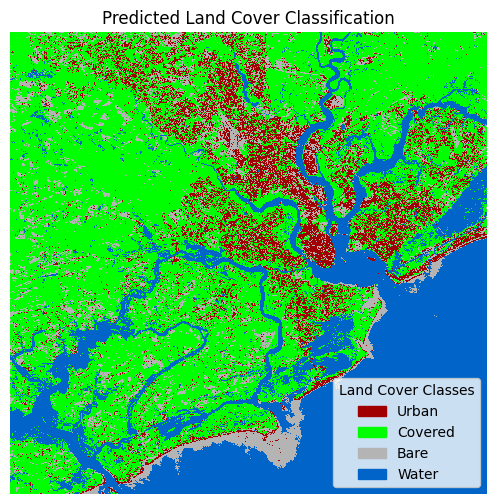

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

# Define land cover classes and colors
class_labels = {
    0: "Urban",
    1: "Covered",
    2: "Bare",
    3: "Water"
}

class_colors = {
    0: "#A00000",  # Urban (Red)
    1: "#00FF00",  # Covered (Green)
    2: "#B4B4B4",  # Bare Land (Gray)
    3: "#0064C8"   # Water (Blue)
}

unique_classes = np.unique(classified_raster)
valid_classes = set(class_labels.keys())
filtered_classes = [cls for cls in unique_classes if cls in valid_classes]

# Create a colormap using class colors
cmap = ListedColormap([class_colors[i] for i in sorted(filtered_classes)])

# Plot the classified raster with the correct colormap
plt.figure(figsize=(8, 6))
plt.imshow(classified_raster, cmap=cmap, interpolation="nearest")
plt.title("Predicted Land Cover Classification")
plt.axis("off")

# Add legend dynamically based on present classes
patches = [mpatches.Patch(color=class_colors[cls], label=class_labels[cls]) for cls in filtered_classes]
plt.legend(handles=patches, loc="lower right", title="Land Cover Classes")

plt.show()

**Export the classified image as a GeoTIFF and the confusion matrix and accuracy metrics to a CSV file for documentation.** 

(See above for codes exporting CSV files)

In [27]:
classified_tiff_path = "classified_landcover.tif"

# Open the original Landsat TIFF to copy metadata
with rasterio.open(tiff_path) as src:
    profile = src.profile  # Copy the original metadata
    transform = src.transform  # Get spatial transformation info

# Update the metadata for the classified TIFF
profile.update(
    dtype=rasterio.uint8,  # Save as an 8-bit integer
    count=1,  # Single-band classification
    compress="lzw"  # Use compression to reduce file size
)

# Save the classified raster as a GeoTIFF
with rasterio.open(classified_tiff_path, "w", **profile) as dst:
    dst.write(classified_raster.astype(rasterio.uint8), 1)  # Write to band 1

print(f"Classified raster exported as {classified_tiff_path}")

Classified raster exported as classified_landcover.tif


## Reflections

**What limitations did you run into when completing this assignment? What might you do differently if you repeated it, or what might you change if you had more time and/or resources?**

My biggest challenge is attempting to apply kernel filter for transforming the data features. Initially, I ran into a lot of errors, and due to the interest of time, I did not explore how to apply features to all bands but only spectual features. This might be the reason why kernel filerting does not improve the baseline model. I would hope to have additional instructions on how to approach the process effectively in the future, and see how kernal filtering could improve the results.

**What was the impact of feature engineering? Which layers most contributed to the model? Did you expect this? Why or why not?**

Among the engineered features, NDVI (0.0550), NDBI (0.0697), and MNDWI (0.0689) contributed moderately, indicating some relevance in capturing vegetation, built-up areas, and water bodies. However, likely due to Charleston's flatter setting, Elevation (0.0430) and Slope (0.0433) had the least influence, which was expected since land cover classification relies more heavily on spectral properties than on terrain characteristics. Overall, while I anticipated spectral bands to be the primary drivers, the spectral indices contributed a fair bit to the prediction to improve its performance.

**Did you find it difficult to create the training data by hand? Did you notice any issues with class imbalance? If so, how might you resolve this in the future (hint: consider a different sampling technique).**

Training data engineering was relatively straightfoward. I didn't run into a huge data imbalance issue because the chosen site has a relatively good distribution of all four types of land use. But would expect the results to work differently in a more urbanized or rural area with unevenly distributed features.

**Did your model perform better on one class than another? Why? Can you think of a reason that this might be good or bad depending on the context?**

As shown in the confusion matric, the model performed best on Water and Covered classes, predicting 34/35 and 41/45 correct predictions respectively. This is likely due to advantageous natural environment surrounding Charleston, particularly the sea and forests. Such performance can be beneficial in applications like flood risk mapping or ecological monitoring

However, the model struggled more with the Bare class, misclassifying 13 instances as Urban and only correctly identifying 27/40 samples. This in fact was the most ambiguous labeling catogory, as barren land and open spaces may be associated very different attributes and uses in the region, ranging from playground to beach, dry soil, and construction sites. This could be problematic in contexts where accurately distinguishing developable land, agricultural land, or degraded land is desired. 